<a href="https://colab.research.google.com/github/miaalvaradoc/IA-TEAM-ASSIGNMENTS/blob/main/FFNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 5.- Artificial Neural Network: feedforward.

*Class Hour: 2:30 - 5:00 p.m. (LMMJV)*


*   Mia Alvarado Cruz - 2114905
*   María Fernanda Soriano Lara - 2177962
*   Ana Lucía Vasquez Andrade - 2095379
*   Alani Monserrath Molina Rosas - 2114717

# Load libraries

This cell imports the necessary libraries: `tensorflow` for building and training the neural network, `numpy` for numerical operations (though not explicitly used in the core model definition, it's a common helper), and `matplotlib.pyplot` for plotting and visualization.

In [42]:
# TensorFlow and tf.keras
import tensorflow as tf

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

# Load data

This cell loads the MNIST dataset using Keras's built-in `mnist.load_data()` function. It automatically splits the data into training (`x_train`, `y_train`) and testing (`x_test`, `y_test`) sets. `x` contains the image data (features) and `y` contains the corresponding labels (digits 0-9).

In [43]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

This cell prints the shapes of the loaded datasets (`x_train`, `y_train`, `x_test`, `y_test`). This helps to verify the dimensions of the data: 60,000 training images and 10,000 test images, each being 28x28 pixels.

In [44]:
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of x_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of x_test: (10000, 28, 28)
Shape of y_test: (10000,)


This cell defines `class_names`, a list of strings representing the digits '0' through '9'. This is used later to interpret the model's predictions and display labels for the images.

In [45]:
class_names = ['0', '1', '2', '3', '4',
               '5', '6', '7', '8', '9']

This cell outputs the number of training labels, which should match the number of training images (60,000 in this case).

In [46]:
len(y_train)

60000

# Data preprocessing

This cell displays the first training image (`x_train[0]`) from the dataset. It uses `matplotlib.pyplot` to show the image in grayscale (`cmap=plt.cm.binary`) and includes a color bar to indicate the pixel intensity values.

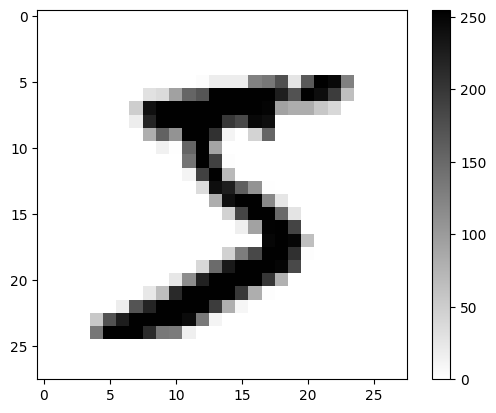

In [47]:
plt.figure()
plt.imshow(x_train[0], cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

This cell preprocesses the image data by normalizing it. Pixel values range from 0 to 255. Dividing by 255.0 scales these values to a range of 0 to 1. This normalization is a common step in neural network training as it helps the model converge faster and perform better.

In [48]:
# The original x_train and x_test contain the unnormalized data.
# We need to normalize them using their own values.
x_train = x_train / 255.0
x_test = x_test / 255.0

This cell displays the first 25 training images in a 5x5 grid. For each image, it shows the pixel data and labels it with its corresponding class name (the actual digit). This helps visualize the dataset after normalization.

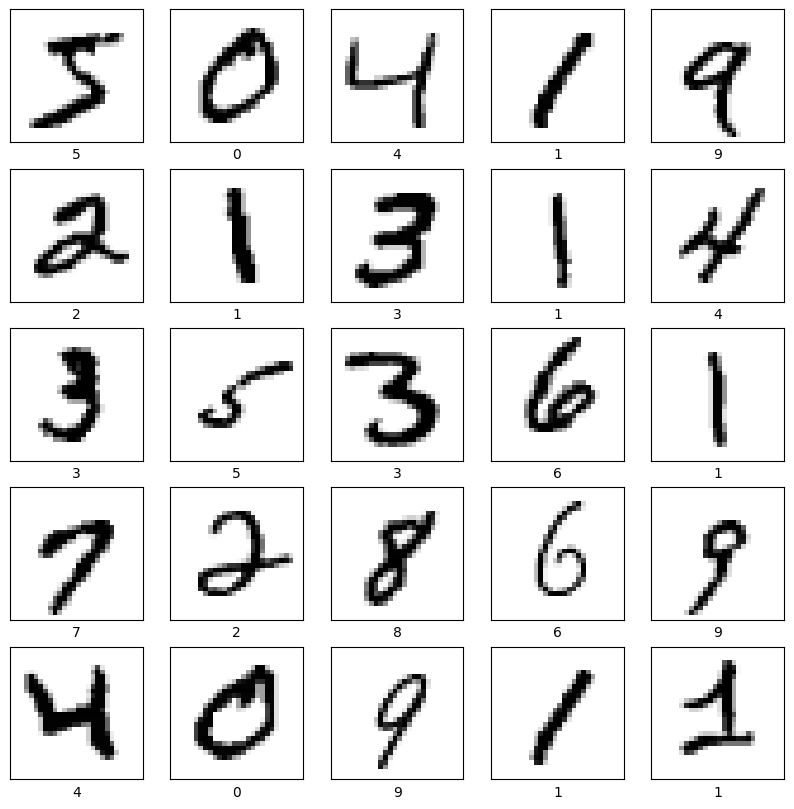

In [49]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

# Model selection and training

This cell defines the architecture of the feedforward artificial neural network using `tf.keras.Sequential`. It consists of:
*   `tf.keras.layers.Flatten`: Transforms the 2D (28x28) image data into a 1D array (784 pixels).
*   `tf.keras.layers.Dense(128, activation='relu')`: A fully connected hidden layer with 128 neurons and a ReLU (Rectified Linear Unit) activation function.
*   `tf.keras.layers.Dense(10)`: The output layer with 10 neurons, corresponding to the 10 digit classes. The activation for this layer is implicitly handled by the loss function with `from_logits=True`.

In [50]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


This cell compiles the model by configuring its learning process:
*   `optimizer='adam'`: Specifies the Adam optimizer, an efficient algorithm for gradient descent.
*   `loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)`: Sets the loss function. `SparseCategoricalCrossentropy` is suitable for integer labels (like our digits), and `from_logits=True` indicates that the output layer provides raw scores (logits) that need to be converted to probabilities by the loss function (e.g., using softmax internally).
*   `metrics=['accuracy']`: Defines the metric to monitor during training and evaluation, in this case, classification accuracy.

In [51]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

This cell trains the neural network using the `model.fit()` method. It feeds the normalized training data (`x_train`, `y_train`) to the model for 10 epochs. An epoch is one full pass through the entire training dataset. During each epoch, the model adjusts its internal parameters to minimize the loss and improve accuracy.

In [52]:
model.fit(x_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9267 - loss: 0.2577
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9665 - loss: 0.1160
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9756 - loss: 0.0802
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9815 - loss: 0.0605
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9859 - loss: 0.0461
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9881 - loss: 0.0379
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9906 - loss: 0.0309
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9925 - loss: 0.0243
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9940 - loss: 0.0192
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9947 - loss: 0.0171


# Model testing

This cell evaluates the trained model's performance on the unseen test dataset (`x_test`, `y_test`) using `model.evaluate()`. It returns the test loss and test accuracy. `verbose=2` prints the results after each epoch (though here it's just one final result).

In [53]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print('\nTest accuracy:', test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.9774 - loss: 0.0820

Test accuracy: 0.977400004863739


This cell creates a `probability_model` by wrapping the trained `model` with an additional `tf.keras.layers.Softmax()` layer. The original model's output layer produced logits, and the Softmax layer converts these logits into probabilities, making the output easier to interpret as class probabilities.

In [54]:
probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])

This cell uses the `probability_model` to make predictions on the entire test dataset (`x_test`). The `predict()` method returns an array where each element is an array of 10 probabilities, indicating the likelihood of the input image belonging to each of the 10 digit classes.

In [55]:
predictions = probability_model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


This cell displays the probability distribution for the first test image (`predictions[0]`). Each value represents the confidence that the image is a particular digit (0-9).

In [56]:
predictions[0]

array([1.3893521e-09, 3.4423067e-10, 2.8469213e-07, 1.5528782e-04,
       1.2958634e-13, 7.6671430e-10, 1.8542431e-13, 9.9984360e-01,
       3.3871570e-09, 7.7674520e-07], dtype=float32)

This cell displays the probability distribution for the 20th test image (`predictions[19]`).

In [57]:
predictions[19]

array([5.1008470e-13, 8.0445411e-10, 3.8807926e-10, 1.4181012e-12,
       9.9999970e-01, 1.6369080e-11, 1.6418587e-10, 3.5128600e-09,
       5.4785360e-11, 2.2138856e-07], dtype=float32)

This cell displays the probability distribution for the 59th test image (`predictions[58]`).

In [58]:
predictions[58]

array([1.0161548e-12, 1.4953889e-15, 7.0145728e-10, 3.4447540e-09,
       1.4629202e-03, 8.8715141e-10, 3.0973244e-13, 8.1013447e-08,
       5.9952571e-11, 9.9853688e-01], dtype=float32)

This cell displays the probability distribution for the 1489th test image (`predictions[1488]`).

In [59]:
predictions[1488]

array([1.8405169e-10, 8.1905175e-19, 6.4581574e-12, 1.6884620e-12,
       9.9964666e-01, 6.9763586e-19, 9.6294570e-12, 2.9024907e-06,
       1.7828483e-11, 3.5047386e-04], dtype=float32)

This cell displays the probability distribution for the last test image (`predictions[9999]`).

In [60]:
predictions[9999]

array([6.1703945e-12, 2.3743436e-19, 6.4609698e-12, 3.4472487e-13,
       1.2003293e-08, 2.1423089e-12, 9.9999994e-01, 9.7278756e-19,
       1.2419394e-16, 7.8455605e-15], dtype=float32)

This cell uses `np.argmax()` to find the index of the highest probability in the prediction array for the first test image. This index corresponds to the model's predicted digit.

In [61]:
np.argmax(predictions[0])

np.int64(7)

This cell shows the predicted digit for the 20th test image.

In [62]:
np.argmax(predictions[19])

np.int64(4)

This cell shows the predicted digit for the 59th test image.

In [63]:
np.argmax(predictions[58])

np.int64(9)

This cell shows the predicted digit for the 1489th test image.

In [64]:
np.argmax(predictions[1488])

np.int64(4)

This cell shows the predicted digit for the last test image.

In [65]:
np.argmax(predictions[9999])

np.int64(6)

This cell displays the actual label (`y_test[0]`) for the first test image, which can be compared to the model's prediction.

In [66]:
y_test[0]

np.uint8(7)

This cell displays the actual label (`y_test[19]`) for the 20th test image.

In [67]:
y_test[19]

np.uint8(4)

This cell displays the actual label (`y_test[58]`) for the 59th test image.

In [68]:
y_test[58]

np.uint8(9)

This cell displays the actual label (`y_test[1488]`) for the 1489th test image.

In [69]:
y_test[1488]

np.uint8(4)

This cell displays the actual label (`y_test[9999]`) for the last test image.

In [70]:
y_test[9999]

np.uint8(6)

This cell defines two helper functions for visualization:
*   `plot_image(i, predictions_array, true_label, img)`: Plots an image, its predicted label, and the true label. It colors correct predictions in blue and incorrect ones in red.
*   `plot_value_array(i, predictions_array, true_label)`: Plots a bar chart of prediction probabilities for each class. The predicted class is highlighted in red, and the true class in blue.

In [71]:
def plot_image(i, predictions_array, true_label, img):
  true_label, img = true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  true_label = true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

This cell uses the `plot_image` and `plot_value_array` functions to visualize the prediction for the first test image (`i=0`). It shows the image, the predicted digit with its confidence, and a bar chart of all class probabilities with the predicted and actual digits highlighted.

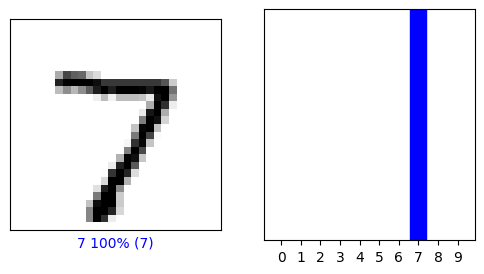

In [72]:
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], y_test, x_test)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  y_test)
plt.show()

This cell visualizes the prediction for the 20th test image (`i=19`) in the same manner as the previous cell.

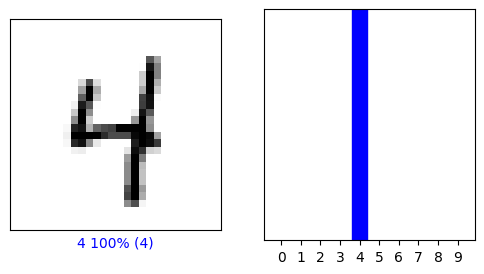

In [73]:
i = 19
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], y_test, x_test)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  y_test)
plt.show()

This cell visualizes the prediction for the 59th test image (`i=58`).

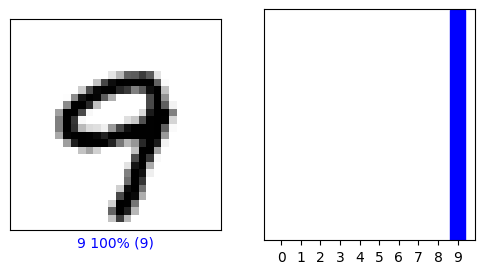

In [74]:
i = 58
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], y_test, x_test)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  y_test)
plt.show()

This cell visualizes the prediction for the 1489th test image (`i=1488`).

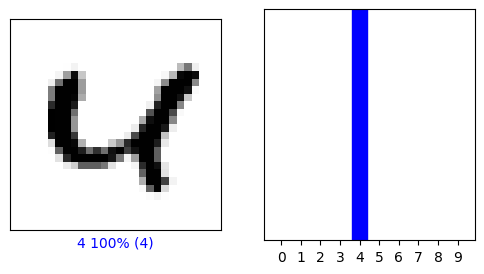

In [75]:
i = 1488
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], y_test, x_test)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  y_test)
plt.show()

This cell visualizes the prediction for the last test image (`i=9999`).

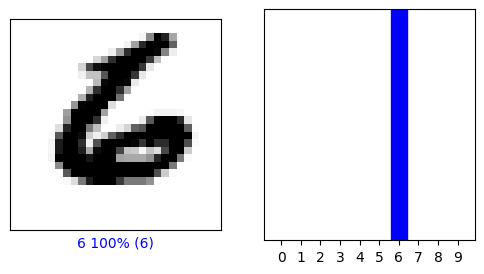

In [76]:
i = 9999
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], y_test, x_test)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  y_test)
plt.show()

This cell plots a grid of the first 15 test images along with their predictions and probability arrays. It's a comprehensive visualization to quickly inspect the model's performance on multiple samples, highlighting correct (blue) and incorrect (red) predictions.

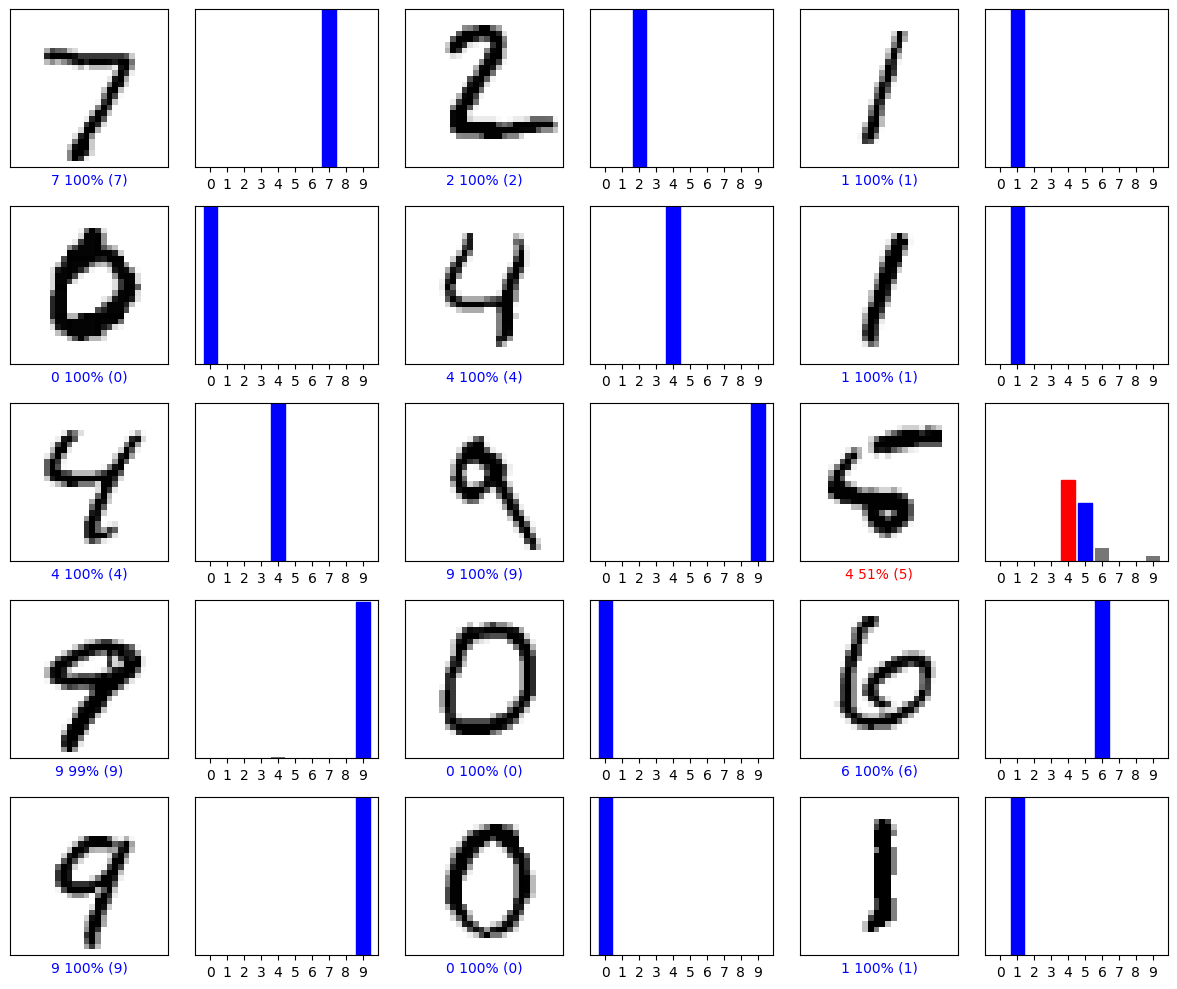

In [77]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], y_test, x_test)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions[i], y_test)
plt.tight_layout()
plt.show()

This cell selects a single image (`x_test[1]`) from the test dataset and prints its shape (28, 28). This is to prepare it for individual prediction.

In [78]:
# Grab an image from the test dataset.
img = x_test[1]

print(img.shape)

(28, 28)


This cell expands the dimensions of the selected image (`img`) from (28, 28) to (1, 28, 28). This is necessary because Keras models expect input in batches, even if it's a batch of one image.

In [79]:
# Add the image to a batch where it's the only member.
img = (np.expand_dims(img,0))

print(img.shape)

(1, 28, 28)


This cell uses the `probability_model` to make a prediction on the single expanded image. It then prints the resulting probability array for that image.

In [80]:
predictions_single = probability_model.predict(img)

print(predictions_single)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[[1.9770590e-09 1.2229070e-06 9.9999332e-01 4.4946619e-06 6.3563345e-19
  7.4796986e-08 8.7140847e-08 1.2451842e-18 7.5519944e-07 1.7289100e-13]]


This cell visualizes the probability distribution for the single image prediction. It uses `plot_value_array` to show the probabilities for each digit, highlighting the predicted class, and sets the x-axis labels to the `class_names`.

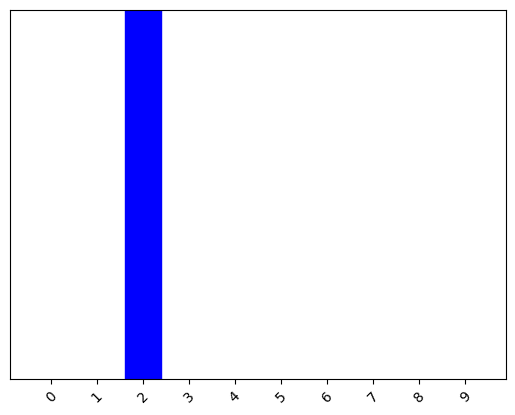

In [81]:
plot_value_array(1, predictions_single[0], y_test)
_ = plt.xticks(range(10), class_names, rotation=45)
plt.show()

This cell extracts the final predicted digit (the one with the highest probability) from the `predictions_single` array using `np.argmax()`.

In [82]:
np.argmax(predictions_single[0])

np.int64(2)